# Pedestrian Trajectory Analysis — Carrefour Melen, Yaounde

Interactive exploration of the Yaounde tracking results and comparison with ETH/UCY benchmarks.

## Dataset overview

| File | Duration | Vantage point |
|---|---|---|
| `Record_1.mp4` | 10m01s | Street level |
| `Record_2.mp4` | 5m00s  | Street level |
| `Record 3.mp4` | 5m00s  | 3rd-floor balcony |
| `Record 4.mp4` | 5m00s  | 3rd-floor balcony |
| `Record 5.mp4` | 5m00s  | 3rd-floor balcony |
| `Record 6.mp4` | 5m00s  | 3rd-floor balcony |

> **Note:** Balcony recordings (3-6) are used for the main trajectory analysis and ETH/UCY comparison,
> as the overhead view minimises occlusion and perspective distortion.

## Workflow
1. Setup & imports
2. Load trajectories (per recording + merged groups)
3. Inspect basic statistics per recording and per group
4. Visualise heatmaps & trajectories
5. Load ETH/UCY data
6. Side-by-side comparison (balcony group vs ETH/UCY)
7. Per-recording breakdown

## 1. Setup & Imports

In [1]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from extract_traj import compute_speeds
from visualize import plot_heatmap, plot_trajectories, plot_speed_distribution
from visualize_interactions import plot_interactions
from compare_eth_ucy import load_eth_ucy, per_pedestrian_stats, plot_comparison

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

# ---------------------------------------------------------------
# Recording registry (mirrors run_all.py)
# ---------------------------------------------------------------
RECORDINGS = [
    ("record_1",  "../data/Record_1.mp4",  "ground"),
    ("record_2",  "../data/Record_2.mp4",  "ground"),
    ("record_3",  "../data/Record 3.mp4",  "balcony"),
    ("record_4",  "../data/Record 4.mp4",  "balcony"),
    ("record_5",  "../data/Record 5.mp4",  "balcony"),
    ("record_6",  "../data/Record 6.mp4",  "balcony"),
]

TRAJ_DIR   = Path("../data/trajectories")
RESULTS_DIR = Path("../results")
ETH_DIR    = Path("../data/eth_ucy")

# Calibration constants (adjust after ground-truth measurement)
FPS      = 30.0
PX_PER_M = {"ground": 50.0, "balcony": 30.0}


## 2. Load Trajectories

In [2]:
# Load individual recordings
dfs = {}
for name, _, group in RECORDINGS:
    csv_path = TRAJ_DIR / f"{name}.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        if "obj_class" in df.columns:
            df = df[df["obj_class"] == 0]
        df["group"] = group
        dfs[name] = df
    else:
        print(f"[WARNING] Not found: {csv_path} — run src/run_all.py first")

# Load merged groups
ground_path  = TRAJ_DIR / "all_ground.csv"
balcony_path = TRAJ_DIR / "all_balcony.csv"

df_ground_full  = pd.read_csv(ground_path)  if ground_path.exists()  else None
df_ground = df_ground_full[df_ground_full["obj_class"] == 0].copy() if df_ground_full is not None and "obj_class" in df_ground_full.columns else df_ground_full
df_balcony_full = pd.read_csv(balcony_path) if balcony_path.exists() else None
df_balcony = df_balcony_full[df_balcony_full["obj_class"] == 0].copy() if df_balcony_full is not None and "obj_class" in df_balcony_full.columns else df_balcony_full

print(f"Individual recordings loaded : {list(dfs.keys())}")
print(f"Ground group  : {len(df_ground)} rows"  if df_ground  is not None else "Ground group  : not found")
print(f"Balcony group : {len(df_balcony)} rows" if df_balcony is not None else "Balcony group : not found")


Individual recordings loaded : ['record_1', 'record_2', 'record_3', 'record_4', 'record_5', 'record_6']
Ground group  : 105737 rows
Balcony group : 129980 rows


## 3. Basic Statistics

### 3a. Per-recording summary

In [3]:
rows = []
for name, _, group in RECORDINGS:
    if name not in dfs:
        continue
    df = dfs[name]
    if "speed_mps" not in df.columns:
        df = compute_speeds(df, fps=FPS, px_per_m=PX_PER_M[group])
    rows.append({
        "recording":    name,
        "group":        group,
        "n_ped":        df["id"].nunique(),
        "n_frames":     df["frame"].nunique(),
        "mean_speed":   round(df["speed_mps"].mean(), 3),
        "median_speed": round(df["speed_mps"].median(), 3),
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))


recording   group  n_ped  n_frames  mean_speed  median_speed
 record_1  ground   1261     16981       4.324         2.131
 record_2  ground   1284      9028       3.963         2.005
 record_3 balcony   1118      8877       1.693         1.230
 record_4 balcony   1450      9003       1.568         1.044
 record_5 balcony    982      8810       1.628         1.145
 record_6 balcony    604      5771       2.072         1.462


### 3b. Group-level statistics

In [4]:
for label, df in [("Ground", df_ground), ("Balcony", df_balcony)]:
    if df is None:
        print(f"{label}: data not available")
        continue
    print(f'\n--- {label} group ---')
    print(f'  Pedestrians : {df["id"].nunique()}')
    print(f'  Rows        : {len(df)}')
    if "speed_mps" in df.columns:
        print(f'  Mean speed  : {df["speed_mps"].mean():.3f} m/s')
        print(f'  Median speed: {df["speed_mps"].median():.3f} m/s')
        print(f'  Max speed: {df["speed_mps"].max():.3f} m/s')



--- Ground group ---
  Pedestrians : 2455
  Rows        : 105737
  Mean speed  : 4.135 m/s
  Median speed: 2.059 m/s
  Max speed: 92.030 m/s

--- Balcony group ---
  Pedestrians : 3617
  Rows        : 129980
  Mean speed  : 1.654 m/s
  Median speed: 1.152 m/s
  Max speed: 29.724 m/s


## 4. Visualisations

### 4a. Density Heatmaps
> Generates `heatmap_balcony.png` and `heatmap.png` (ground) and displays them inline.

--- Balcony Group Heatmap ---
[visualize] Heatmap saved to ..\results\heatmap_balcony.png


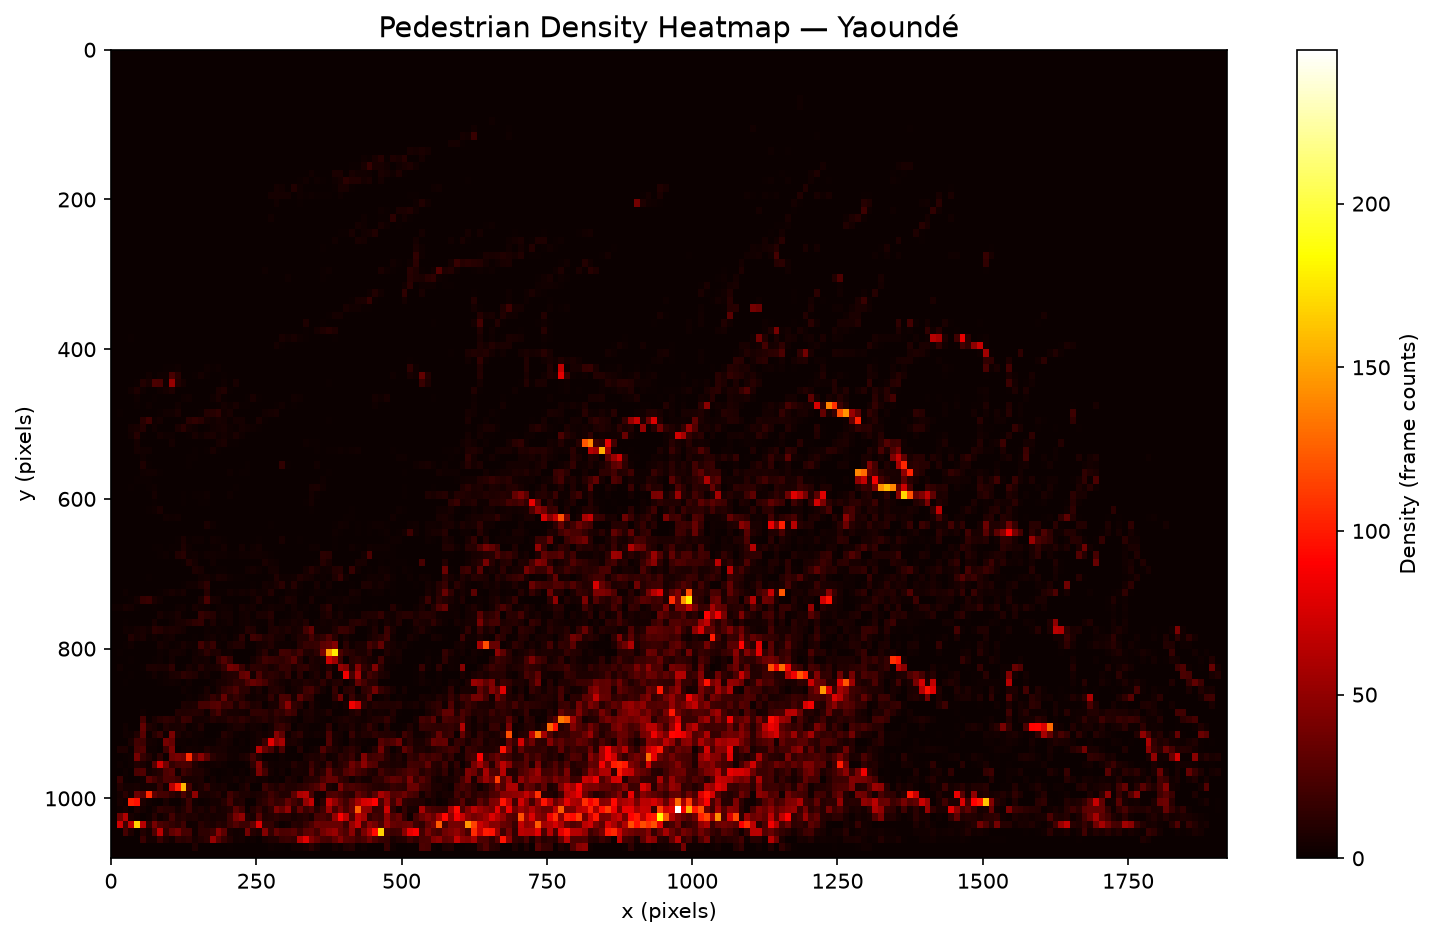

--- Ground Group Heatmap ---
[visualize] Heatmap saved to ..\results\heatmap.png


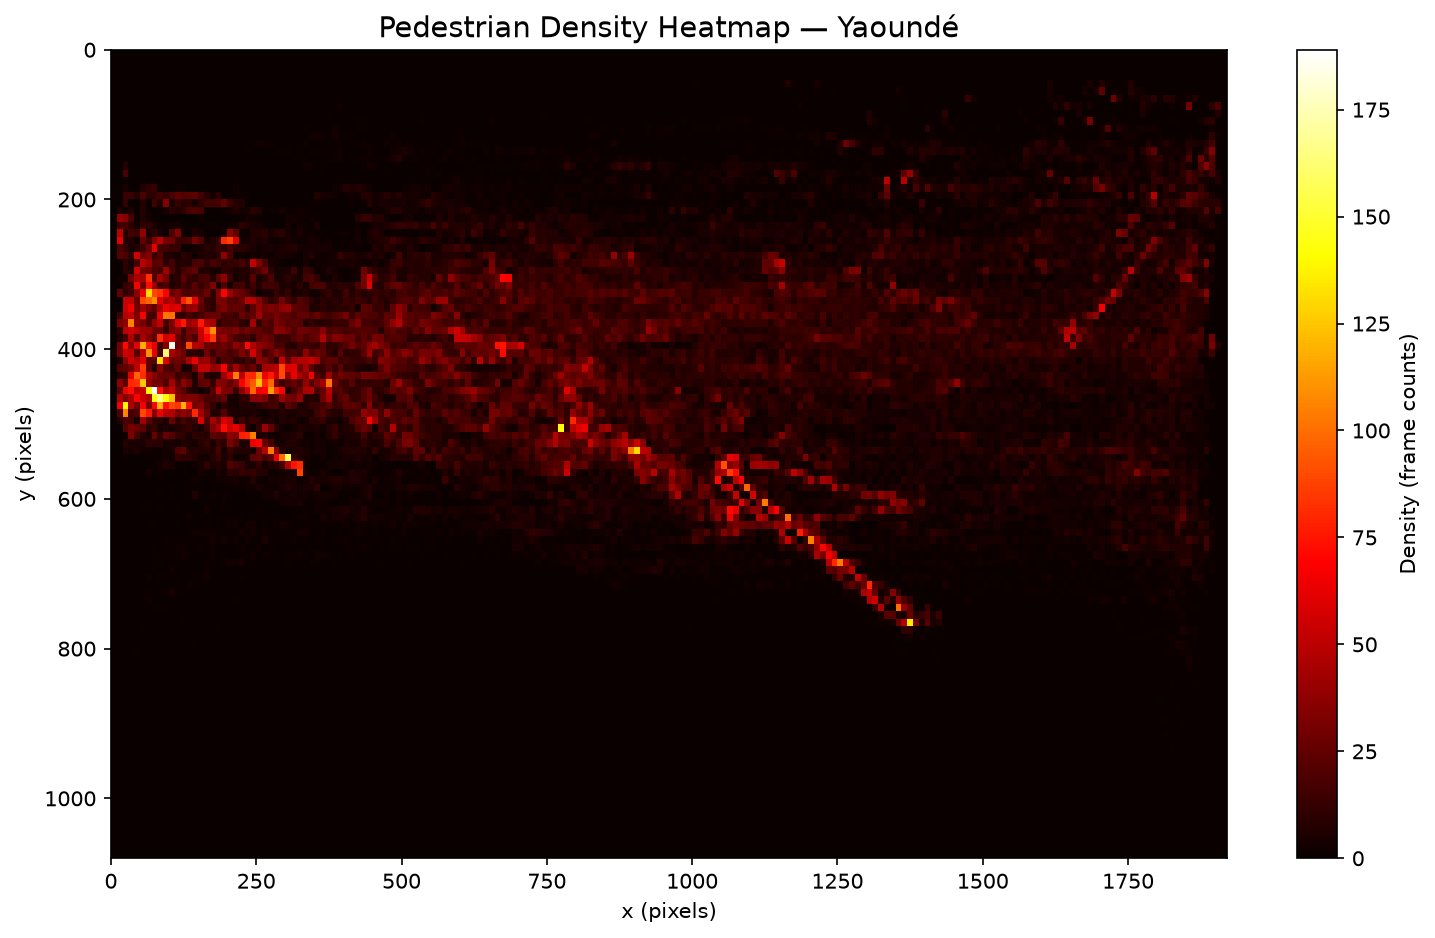

In [5]:
from IPython.display import Image, display

print("--- Balcony Group Heatmap ---")
if df_balcony is not None:
    out_balcony = str(RESULTS_DIR / "heatmap_balcony.png")
    plot_heatmap(df_balcony, frame_w=1920, frame_h=1080, output=out_balcony)
    display(Image(filename=out_balcony))
else:
    print("Balcony data not available — skipping heatmap.\n")

print("--- Ground Group Heatmap ---")
if df_ground is not None:
    out_ground = str(RESULTS_DIR / "heatmap.png")
    plot_heatmap(df_ground, frame_w=1920, frame_h=1080, output=out_ground)
    display(Image(filename=out_ground))
else:
    print("Ground data not available — skipping heatmap.\n")


### 4b. Trajectory overlay — per recording

Saved -> ..\results\trajectories_per_recording.png


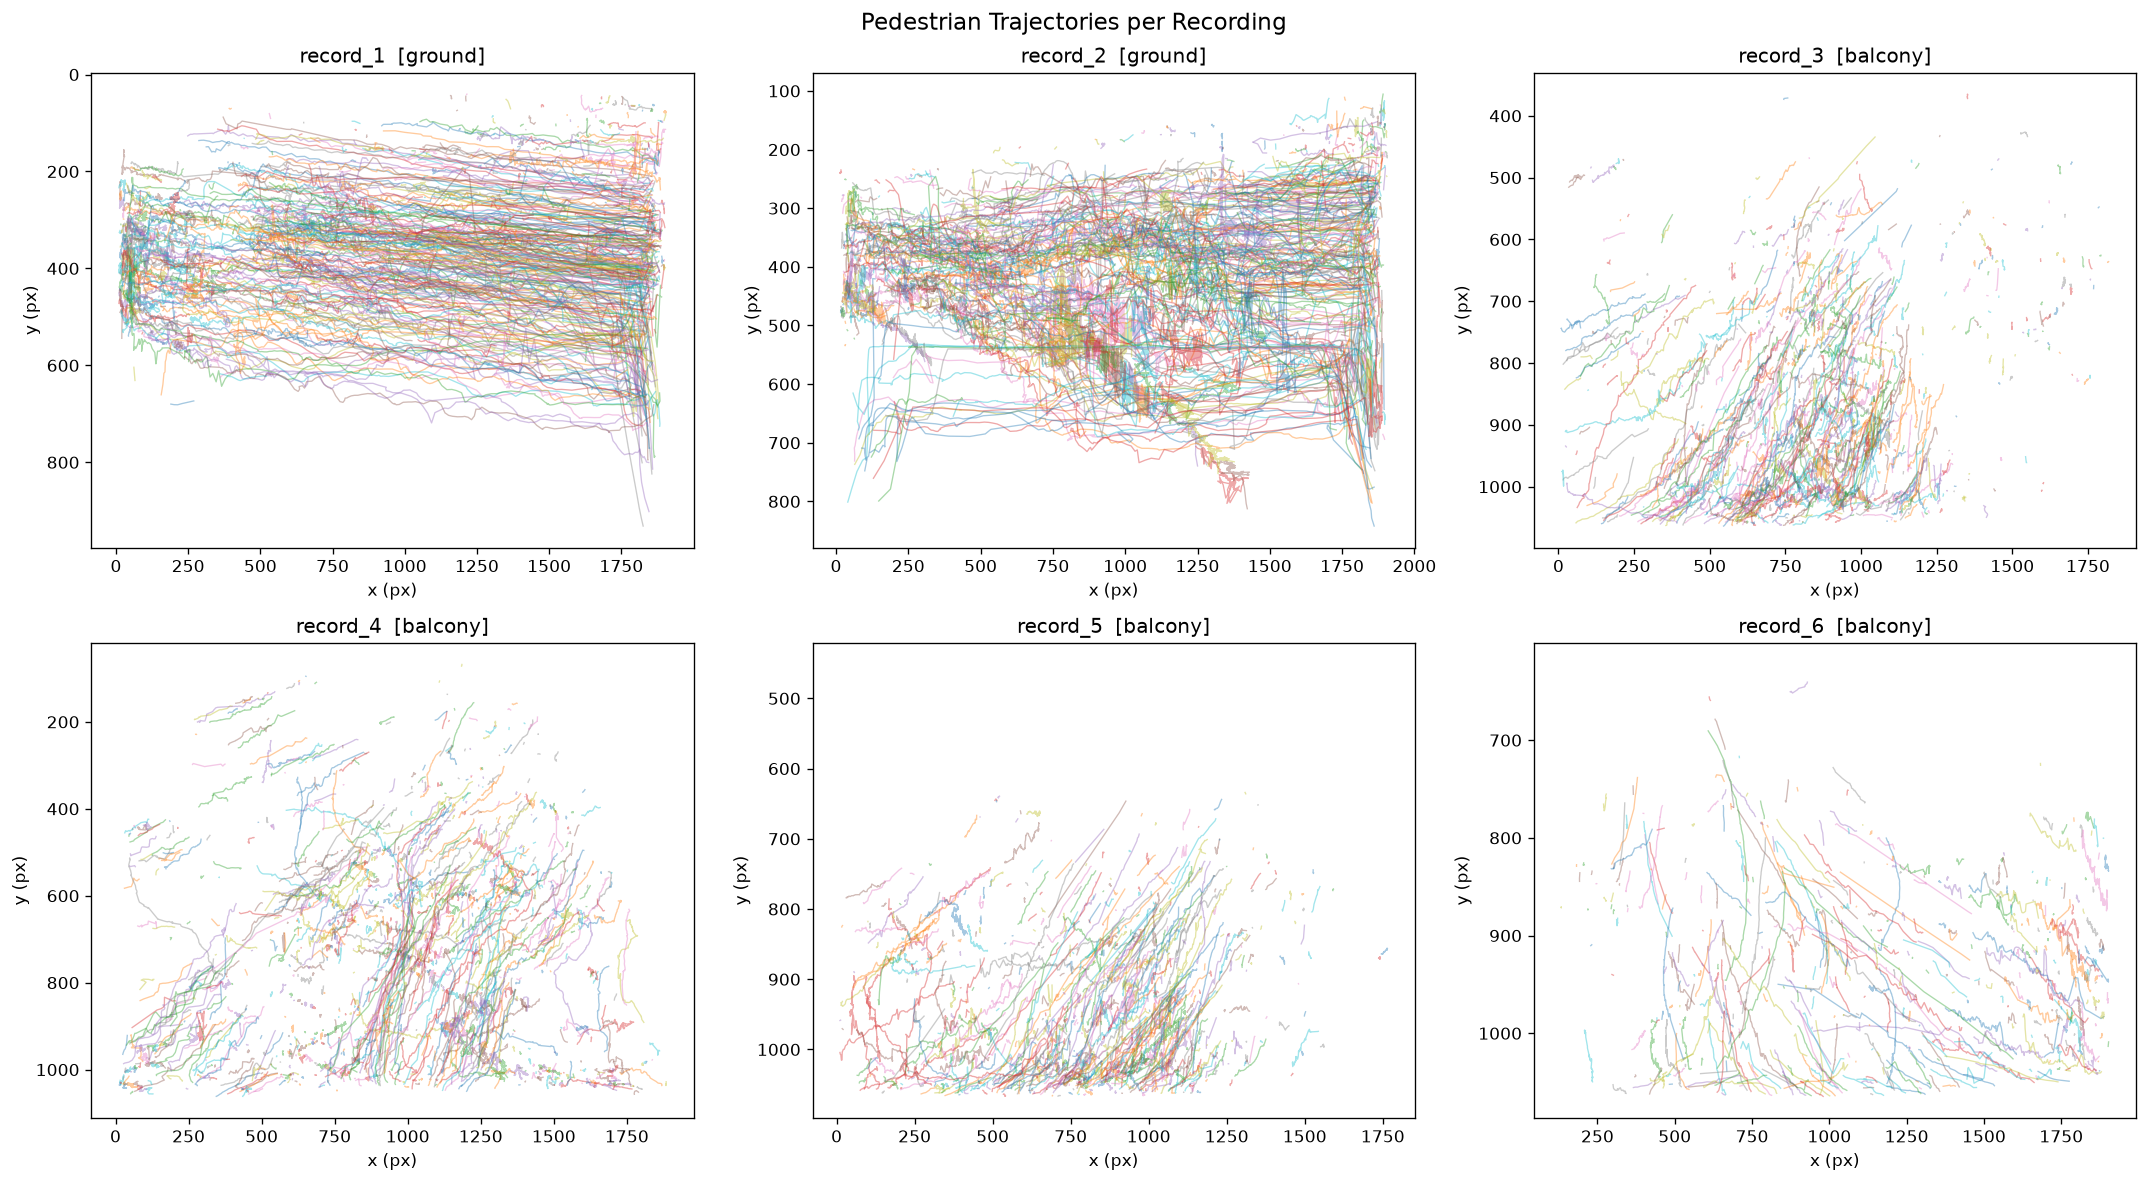

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Pedestrian Trajectories per Recording", fontsize=14)
colors = cm.tab10.colors

for ax, (name, _, group) in zip(axes.flat, RECORDINGS):
    if name not in dfs:
        ax.set_title(f"{name} (no data)")
        ax.axis("off")
        continue
    df = dfs[name]
    for i, (pid, traj) in enumerate(df.groupby("id")):
        ax.plot(traj["x"], traj["y"], alpha=0.4, linewidth=0.8,
                color=colors[i % len(colors)])
    ax.set_title(f"{name}  [{group}]")
    ax.set_xlabel("x (px)")
    ax.set_ylabel("y (px)")
    ax.invert_yaxis()

plt.tight_layout()
out = RESULTS_DIR / "trajectories_per_recording.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved -> {out}")
plt.show()


### 4c. Speed distribution — ground vs balcony

Saved -> ..\results\speed_ground_vs_balcony.png


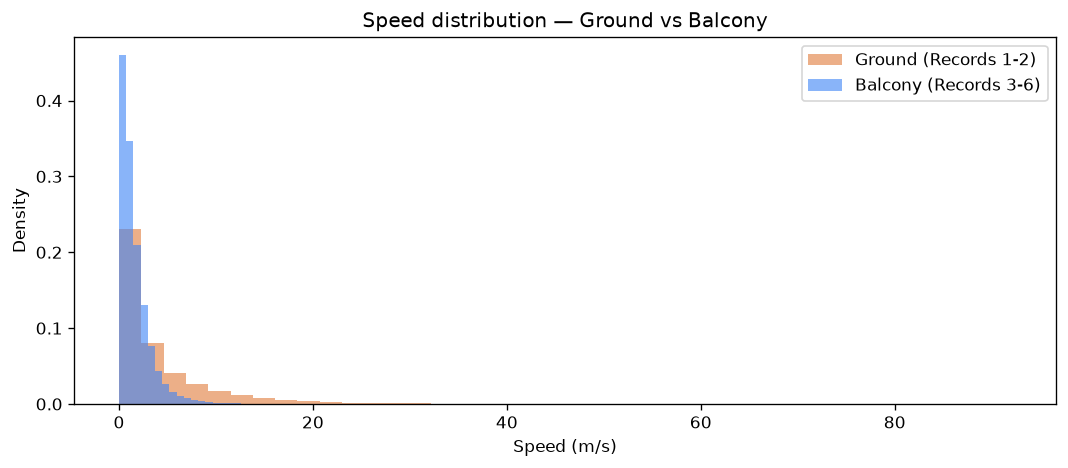

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, df, color in [
        ("Ground (Records 1-2)",  df_ground,  "#e07b39"),
        ("Balcony (Records 3-6)", df_balcony, "#3b82f6")]:
    if df is not None and "speed_mps" in df.columns:
        ax.hist(df["speed_mps"].dropna(), bins=40, alpha=0.6,
                color=color, label=label, density=True)

ax.set_xlabel("Speed (m/s)")
ax.set_ylabel("Density")
ax.set_title("Speed distribution — Ground vs Balcony")
ax.legend()
fig.tight_layout()
out = RESULTS_DIR / "speed_ground_vs_balcony.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved -> {out}")
plt.show()


### 4c. Interactions Piétons/Véhicules

[visualize_interactions] Found 26172 conflict points.
[visualize_interactions] Interactions plot saved to ..\results\interactions_heatmap.png


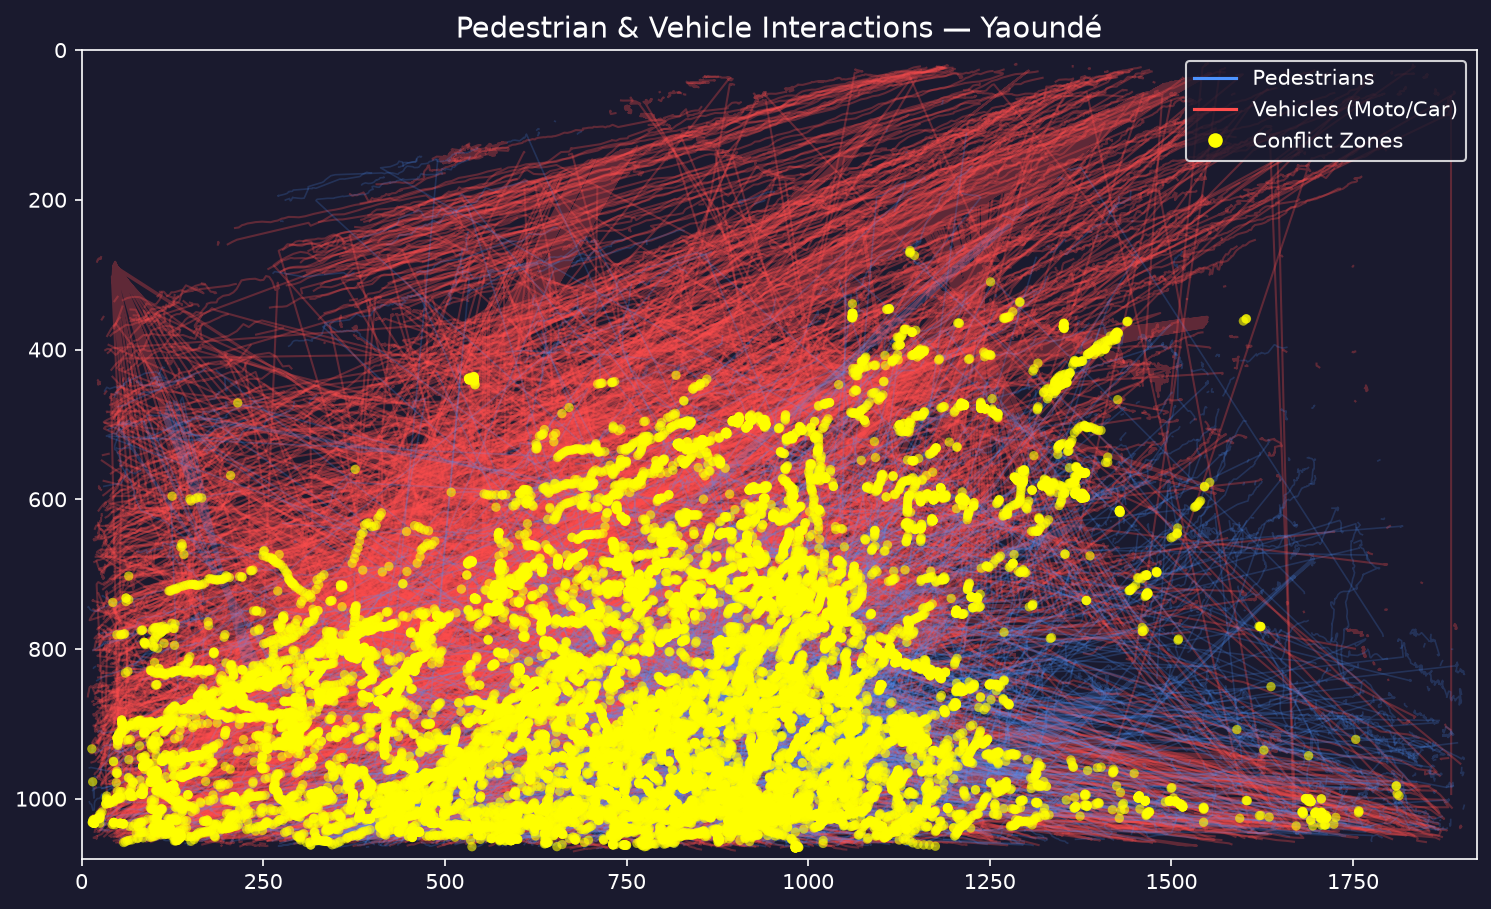

In [8]:
if df_balcony_full is not None:
    out_img = str(RESULTS_DIR / "interactions_heatmap.png")
    plot_interactions(df_balcony_full, frame_w=1920, frame_h=1080, output=out_img)
    
    from IPython.display import Image, display
    display(Image(filename=out_img))
else:
    print("Balcony data not available — skipping interactions.")


### 4d. Overall Speed Distribution
> Generate `speed_distribution.png` for all valid trajectories.

[visualize] Speed distribution saved to ..\results\speed_distribution.png


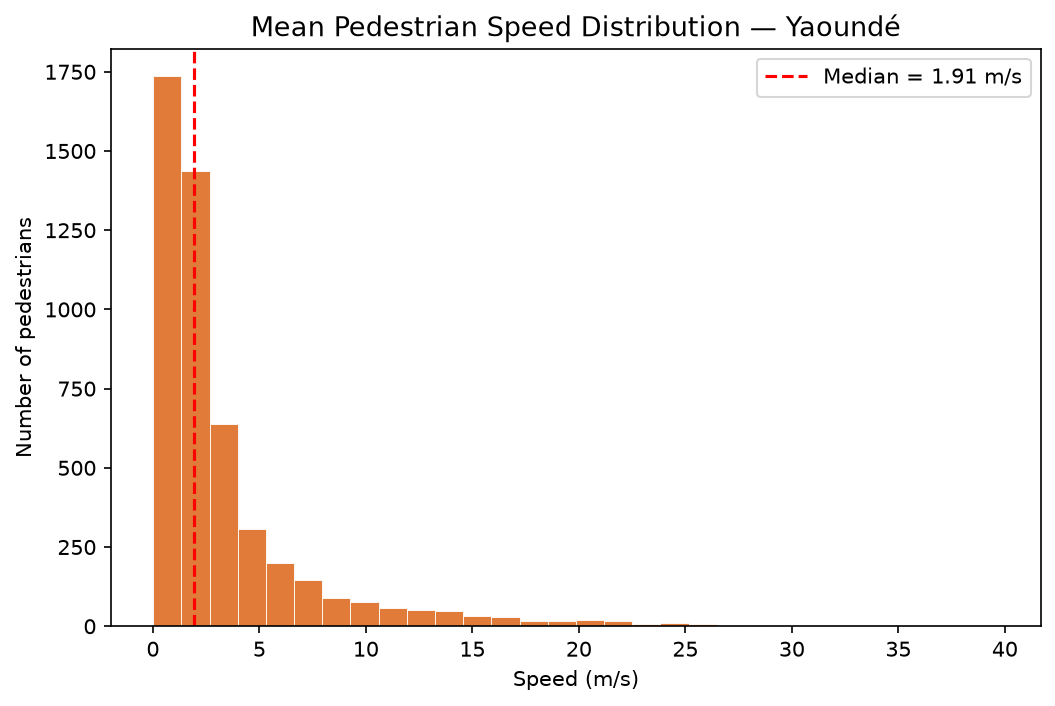

In [9]:
dfs_to_concat = []
if df_ground is not None:
    dfs_to_concat.append(df_ground)
if df_balcony is not None:
    dfs_to_concat.append(df_balcony)

if dfs_to_concat:
    df_all = pd.concat(dfs_to_concat)
    if "speed_mps" not in df_all.columns:
        # fallback in case speed_mps was not in the merged CSVs
        print("Speed not found in merged CSVs.")
    else:
        out_path = str(RESULTS_DIR / "speed_distribution.png")
        plot_speed_distribution(df_all, output=out_path)
        
        from IPython.display import Image, display
        display(Image(filename=out_path))
else:
    print("No data available to plot overall speed distribution.")


## 5. Load ETH/UCY Benchmark Data

In [ ]:
eth_df = load_eth_ucy(str(ETH_DIR), fps=2.5)
eth_stats = per_pedestrian_stats(eth_df, label="ETH/UCY")
print(f'ETH/UCY: {eth_df["id"].nunique()} pedestrians across {eth_df["dataset"].nunique()} scenes')
eth_df.head()


ETH/UCY: 434 pedestrians across 8 scenes


,frame,id,x,y,dataset,speed_mps
0,780.0,1.0,8.46,3.59,biwi_eth,NaN
1,790.0,1.0,9.57,3.79,biwi_eth,0.281969
2,800.0,1.0,10.67,3.99,biwi_eth,0.279508
4,810.0,1.0,11.73,4.32,biwi_eth,0.277545
6,820.0,1.0,12.81,4.61,biwi_eth,0.279564


## 6. Comparison: Balcony group vs ETH/UCY

> Using the **balcony recordings** (3-6) for comparison as they share the overhead perspective of ETH/UCY.

In [11]:
if df_balcony is not None:
    # Convert pixel coords to metres for fair comparison
    df_bal_m = df_balcony.copy()
    df_bal_m["x"] = df_bal_m["x"] / PX_PER_M["balcony"]
    df_bal_m["y"] = df_bal_m["y"] / PX_PER_M["balcony"]
    balcony_stats = per_pedestrian_stats(df_bal_m, label="Yaounde (balcony)")
    plot_comparison(balcony_stats, eth_stats, output_dir=str(RESULTS_DIR))
else:
    print("Balcony data not available.")


[compare] Comparison plot saved to ..\results/speed_comparison.png
[compare] Summary table saved to ..\results/comparison_summary.csv
            Metric Yaounde ETH/UCY
  Mean speed (m/s)   2.001   0.122
Median path length     1.5    13.5
  Median linearity   0.808   0.981


## 7. Per-recording Breakdown

Saved -> ..\results\speed_per_recording.png


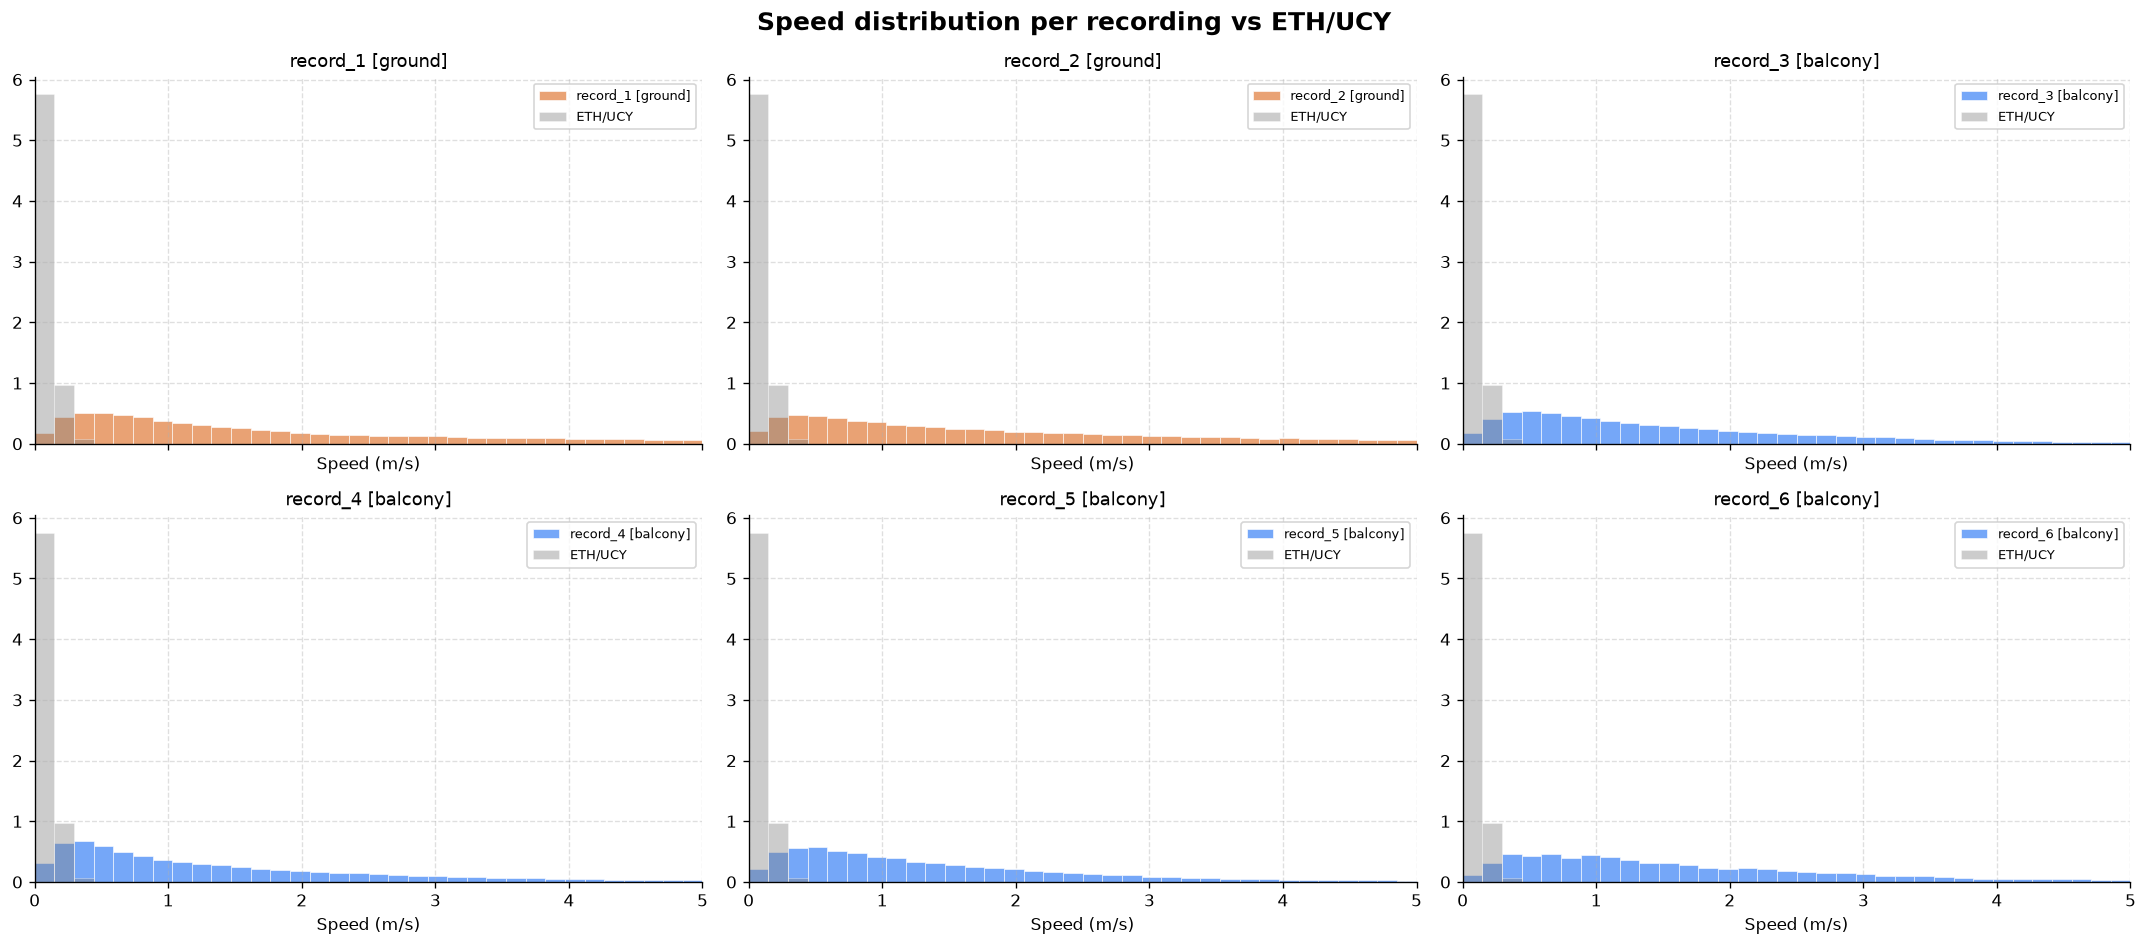

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
fig.suptitle("Speed distribution per recording vs ETH/UCY", fontsize=15, fontweight="bold")

eth_speeds = eth_df["speed_mps"].dropna()

# 1. Définir une vitesse maximale cohérente (ex: 5 m/s) et des bins uniformes
MAX_SPEED = 5.0 
common_bins = np.linspace(0, MAX_SPEED, 35)

for ax, (name, _, group) in zip(axes.flat, RECORDINGS):
    if name not in dfs:
        ax.set_title(f"{name} (no data)", fontsize=11)
        ax.axis("off")
        continue
        
    df = dfs[name]
    if "speed_mps" not in df.columns:
        df = compute_speeds(df, fps=FPS, px_per_m=PX_PER_M[group])
        
    speeds = df["speed_mps"].dropna()

    # 2. Utiliser common_bins et ajouter un contour blanc aux barres
    ax.hist(speeds, bins=common_bins, alpha=0.7,
            color="#e07b39" if group == "ground" else "#3b82f6",
            label=f"{name} [{group}]", density=True, edgecolor="white", linewidth=0.5)
            
    ax.hist(eth_speeds, bins=common_bins, alpha=0.4, color="gray",
            label="ETH/UCY", density=True, edgecolor="white", linewidth=0.5)
            
    ax.set_title(f"{name} [{group}]", fontsize=11)
    ax.set_xlabel("Speed (m/s)")
    ax.set_xlim(0, MAX_SPEED)
    
    # 3. Améliorer l'esthétique (grille et nettoyage des bordures)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=8)

plt.tight_layout()
out = RESULTS_DIR / "speed_per_recording.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved -> {out}")
plt.show()